In [ ]:
import tensorflow as tf

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

Physical devices cannot be modified after being initialized


In [ ]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0,ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input, Concatenate
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Enable mixed precision training
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

# Ensure seaborn plots are displayed
sns.set()


C:\Users\HP\anaconda3\envs\myenv\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: Quadro T2000, compute capability 7.5


In [ ]:
# Data directory paths
activity_data_dir = r'C:\Users\HP\CSAD\data_1\activity'
faces_data_dir = r'C:\Users\HP\CSAD\data_1\faces'

# Image data generators
datagen = ImageDataGenerator(rescale=1.0/255.0)

# Load activity data
train_activity = datagen.flow_from_directory(os.path.join(activity_data_dir, 'train'), target_size=(224, 224), batch_size=16, class_mode='categorical')
valid_activity = datagen.flow_from_directory(os.path.join(activity_data_dir, 'valid'), target_size=(224, 224), batch_size=16, class_mode='categorical')
test_activity = datagen.flow_from_directory(os.path.join(activity_data_dir, 'test'), target_size=(224, 224), batch_size=16, class_mode='categorical', shuffle=False)

# Load face data
train_faces = datagen.flow_from_directory(os.path.join(faces_data_dir, 'train'), target_size=(224, 224), batch_size=16, class_mode='categorical')
valid_faces = datagen.flow_from_directory(os.path.join(faces_data_dir, 'valid'), target_size=(224, 224), batch_size=16, class_mode='categorical')
test_faces = datagen.flow_from_directory(os.path.join(faces_data_dir, 'test'), target_size=(224, 224), batch_size=16, class_mode='categorical', shuffle=False)

Found 2927 images belonging to 3 classes.
Found 1559 images belonging to 3 classes.
Found 919 images belonging to 3 classes.
Found 125 images belonging to 3 classes.
Found 69 images belonging to 3 classes.
Found 56 images belonging to 3 classes.


In [ ]:
# Function to create a model
def create_base_model(base_model, num_classes, input_shape=(224, 224, 3)):
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(1024, activation='relu')(x)
    predictions = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=predictions)
    return model

# Activity recognition base models
activity_base_models = [
    create_base_model(ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3)), train_activity.num_classes),
    create_base_model(EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3)), train_activity.num_classes)
]

# Facial recognition base models
face_base_models = [
    create_base_model(MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3)), train_faces.num_classes),
    create_base_model(EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3)), train_faces.num_classes)
]

In [ ]:
# Function to create a stacking model
def create_stacking_model(base_models, num_classes, input_shape=(224, 224, 3)):
    # Inputs
    model_inputs = [Input(shape=(num_classes,)) for _ in base_models]

    # Concatenate outputs of base models
    merged = Concatenate()(model_inputs)

    # Add dense layers for meta-learning
    x = Dense(512, activation='relu')(merged)
    x = Dense(256, activation='relu')(x)
    predictions = Dense(num_classes, activation='softmax')(x)

    # Define model
    stacking_model = Model(inputs=model_inputs, outputs=predictions)
    stacking_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    return stacking_model

# Create stacking models for activity and face recognition
activity_stacking_model = create_stacking_model(activity_base_models, train_activity.num_classes)
face_stacking_model = create_stacking_model(face_base_models, train_faces.num_classes)

In [ ]:
# Compile the base models
for model in activity_base_models + face_base_models:
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
def train_base_models_and_generate_predictions(base_models, train_data, val_data, test_data, task_name):
    # Train each base model and generate predictions for stacking
    train_predictions = []
    val_predictions = []
    test_predictions = []
    
    for i, model in enumerate(base_models):
        print(f"Training base model {i+1} for {task_name}")
        model.fit(train_data, validation_data=val_data, epochs=10)
        
        # Generate predictions
        train_pred = model.predict(train_data)
        val_pred = model.predict(val_data)
        test_pred = model.predict(test_data)
        
        train_predictions.append(train_pred)
        val_predictions.append(val_pred)
        test_predictions.append(test_pred)
    
    return np.array(train_predictions), np.array(val_predictions), np.array(test_predictions)

# Train base models and generate predictions for activity and face recognition
train_activity_preds, val_activity_preds, test_activity_preds = train_base_models_and_generate_predictions(activity_base_models, train_activity, valid_activity, test_activity, "Activity_Recognition")
train_face_preds, val_face_preds, test_face_preds = train_base_models_and_generate_predictions(face_base_models, train_faces, valid_faces, test_faces, "Face_Recognition")

Training base model 1 for Activity_Recognition
Epoch 1/10
183/183 [==============================] - 182s 911ms/step - loss: 1.1911 - accuracy: 0.2603 - val_loss: 1.2628 - val_accuracy: 0.2072
Epoch 2/10
183/183 [==============================] - 166s 906ms/step - loss: 1.1935 - accuracy: 0.2487 - val_loss: 1.1761 - val_accuracy: 0.2540
Epoch 3/10
183/183 [==============================] - 162s 887ms/step - loss: 1.1908 - accuracy: 0.2579 - val_loss: 1.3574 - val_accuracy: 0.0680
Epoch 4/10
183/183 [==============================] - 143s 780ms/step - loss: 1.1905 - accuracy: 0.2593 - val_loss: 1.1372 - val_accuracy: 0.4099
Epoch 5/10
183/183 [==============================] - 140s 765ms/step - loss: 1.1884 - accuracy: 0.2627 - val_loss: 1.2065 - val_accuracy: 0.1944
Epoch 6/10
183/183 [==============================] - 140s 765ms/step - loss: 1.1855 - accuracy: 0.2740 - val_loss: 1.1432 - val_accuracy: 0.2219
Epoch 7/10
183/183 [==============================] - 140s 765ms/step - loss:

In [ ]:
from tensorflow.keras.utils import to_categorical

In [ ]:
def train_stacking_model(stacking_model_fn, train_preds, val_preds, train_data, val_data, task_name):
    print(f"Training stacking model for {task_name}")

    # Rebuild stacking model
    stacking_model = stacking_model_fn()
    
    # Ensure the labels are one-hot encoded
    train_labels = to_categorical(train_data.classes, num_classes=train_data.num_classes)
    val_labels = to_categorical(val_data.classes, num_classes=val_data.num_classes)
    
    # Fit the model
    stacking_model.fit(
        [pred for pred in train_preds], 
        train_labels, 
        validation_data=([pred for pred in val_preds], val_labels), 
        epochs=20
    )

    return stacking_model

# Modify your stacking model creation to return a function that builds the model
def create_stacking_model_fn(base_models, num_classes):
    def stacking_model_fn():
        # Inputs for stacking model
        model_inputs = [Input(shape=(num_classes,)) for _ in base_models]

        # Concatenate outputs of base models
        merged = Concatenate()(model_inputs)

        # Add dense layers for meta-learning
        x = Dense(512, activation='relu')(merged)
        x = Dense(256, activation='relu')(x)
        predictions = Dense(num_classes, activation='softmax')(x)

        # Define model
        stacking_model = Model(inputs=model_inputs, outputs=predictions)
        stacking_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
        
        return stacking_model
    
    return stacking_model_fn

# Create stacking model functions
activity_stacking_model_fn = create_stacking_model_fn(activity_base_models, train_activity.num_classes)
face_stacking_model_fn = create_stacking_model_fn(face_base_models, train_faces.num_classes)

# Train stacking models for activity and face recognition
activity_stacking_model = train_stacking_model(activity_stacking_model_fn, train_activity_preds, val_activity_preds, train_activity, valid_activity, "Activity_Recognition")
face_stacking_model = train_stacking_model(face_stacking_model_fn, train_face_preds, val_face_preds, train_faces, valid_faces, "Face_Recognition")


Training stacking model for Activity_Recognition
Epoch 1/20
92/92 [==============================] - 2s 10ms/step - loss: 1.1010 - accuracy: 0.3413 - val_loss: 1.0973 - val_accuracy: 0.2893
Epoch 2/20
92/92 [==============================] - 1s 6ms/step - loss: 1.1003 - accuracy: 0.3399 - val_loss: 1.1090 - val_accuracy: 0.2874
Epoch 3/20
92/92 [==============================] - 1s 6ms/step - loss: 1.0995 - accuracy: 0.3406 - val_loss: 1.1009 - val_accuracy: 0.2874
Epoch 4/20
92/92 [==============================] - 1s 6ms/step - loss: 1.0988 - accuracy: 0.3348 - val_loss: 1.0791 - val_accuracy: 0.4631
Epoch 5/20
92/92 [==============================] - 1s 6ms/step - loss: 1.0988 - accuracy: 0.3334 - val_loss: 1.0904 - val_accuracy: 0.3669
Epoch 6/20
92/92 [==============================] - 1s 6ms/step - loss: 1.0981 - accuracy: 0.3495 - val_loss: 1.0796 - val_accuracy: 0.5003
Epoch 7/20
92/92 [==============================] - 1s 6ms/step - loss: 1.0983 - accuracy: 0.3406 - val_loss: 

Evaluating stacking model for Activity_Recognition
29/29 [==============================] - 0s 3ms/step


C:\Users\HP\anaconda3\envs\myenv\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\anaconda3\envs\myenv\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\anaconda3\envs\myenv\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


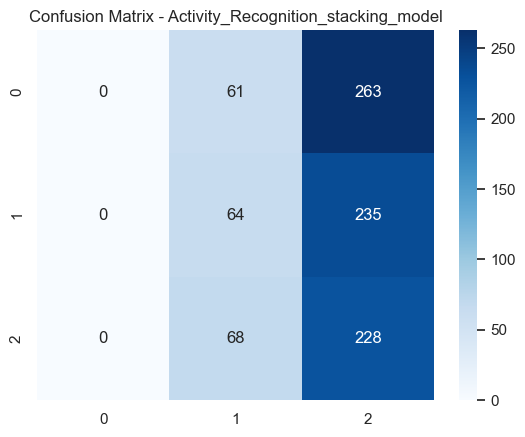

Evaluating stacking model for Face_Recognition
2/2 [==============================] - 0s 5ms/step


C:\Users\HP\anaconda3\envs\myenv\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\anaconda3\envs\myenv\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\anaconda3\envs\myenv\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


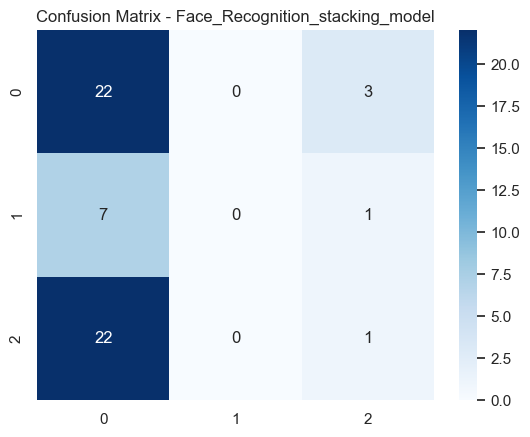

In [ ]:
def evaluate_stacking_model(stacking_model, test_preds, test_data, task_name):
    print(f"Evaluating stacking model for {task_name}")
    
    preds = stacking_model.predict([pred for pred in test_preds])
    y_true = test_data.classes
    y_pred = preds.argmax(axis=1)
    
    report = classification_report(y_true, y_pred, target_names=list(test_data.class_indices.keys()))
    cm = confusion_matrix(y_true, y_pred)
    
    model_name = f"{task_name}_stacking_model"
    os.makedirs(f"results/{model_name}", exist_ok=True)
    
    with open(f"results/{model_name}/report.txt", "w") as f:
        f.write(report)
    
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.savefig(f"results/{model_name}/confusion_matrix.png")
    plt.show()

# Evaluate stacking models for activity and face recognition
evaluate_stacking_model(activity_stacking_model, test_activity_preds, test_activity, "Activity_Recognition")
evaluate_stacking_model(face_stacking_model, test_face_preds, test_faces, "Face_Recognition")

In [ ]:
def real_time_activity_and_face_recognition_with_stacking(activity_base_models, face_base_models, activity_stacking_model, face_stacking_model):
    cap = cv2.VideoCapture(0)
    cv2.namedWindow("Real-Time Activity and Face Recognition", cv2.WND_PROP_FULLSCREEN)
    cv2.setWindowProperty("Real-Time Activity and Face Recognition", cv2.WND_PROP_FULLSCREEN, cv2.WINDOW_FULLSCREEN)

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Preprocess the frame for the models
        input_frame = cv2.resize(frame, (224, 224))
        input_frame = np.expand_dims(input_frame, axis=0)

        # Get predictions from all activity models
        activity_predictions = [model.predict(input_frame) for model in activity_base_models]
        activity_stacking_prediction = activity_stacking_model.predict(activity_predictions).argmax()

        # Get predictions from all face models
        face_predictions = [model.predict(input_frame) for model in face_base_models]
        face_stacking_prediction = face_stacking_model.predict(face_predictions).argmax()

        # Display results on the screen
        activity_label = list(train_activity.class_indices.keys())[activity_stacking_prediction]
        face_label = list(train_faces.class_indices.keys())[face_stacking_prediction]

        cv2.putText(frame, f"Activity: {activity_label}", (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
        cv2.putText(frame, f"Face: {face_label}", (50, 100), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

        cv2.imshow("Real-Time Activity and Face Recognition", frame)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

In [ ]:
real_time_activity_and_face_recognition_with_stacking(activity_base_models, face_base_models, activity_stacking_model, face_stacking_model)

NameError: name 'activity_base_models' is not defined

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


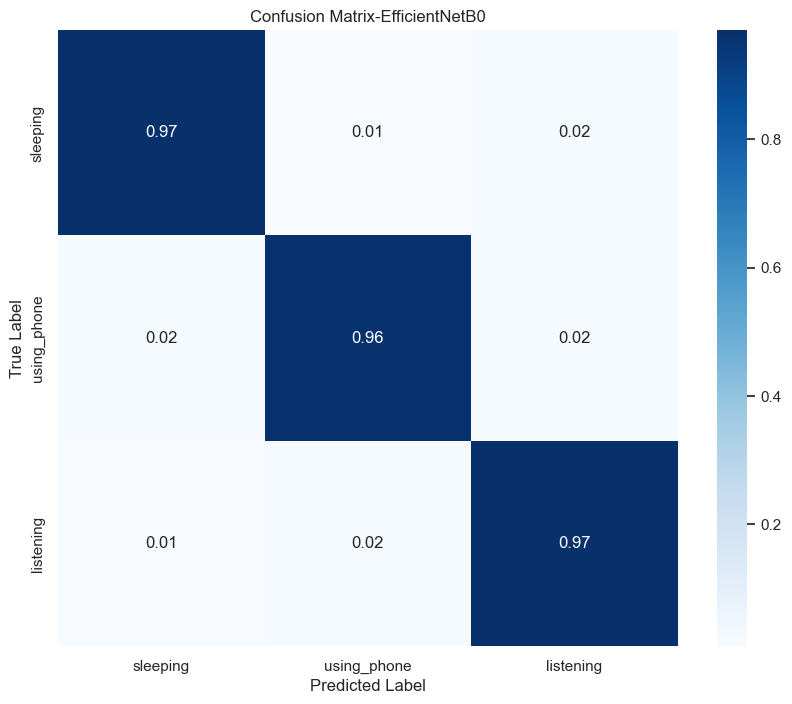

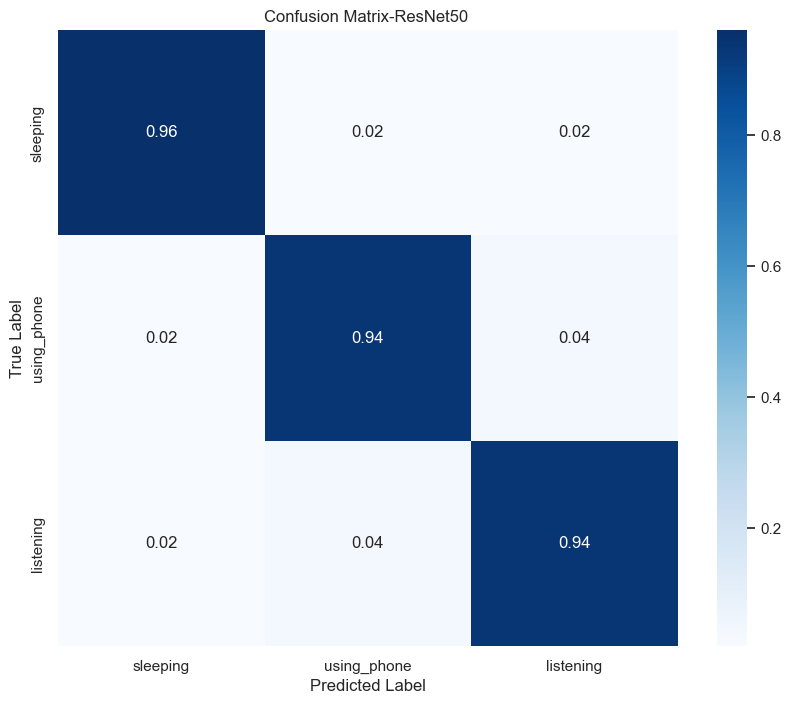

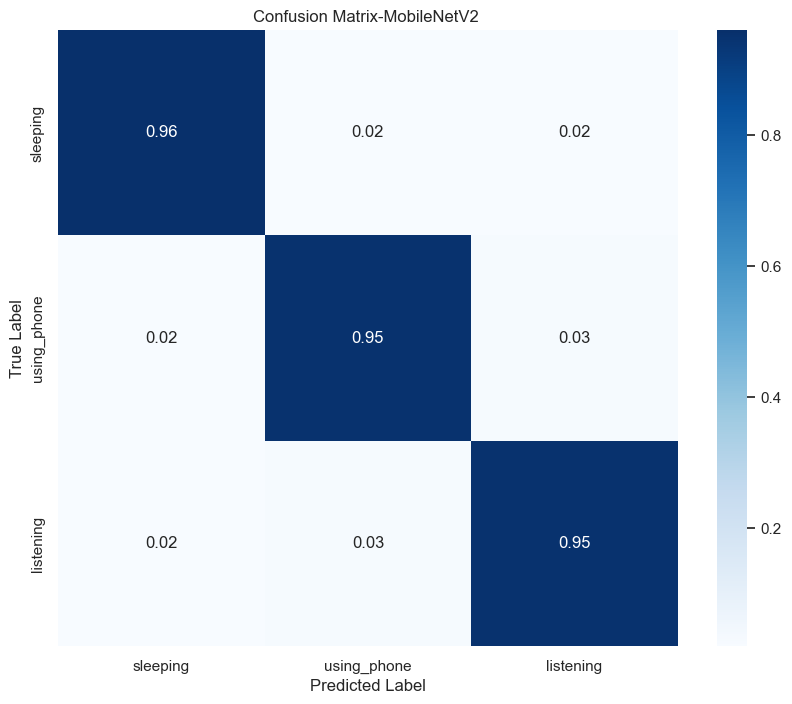

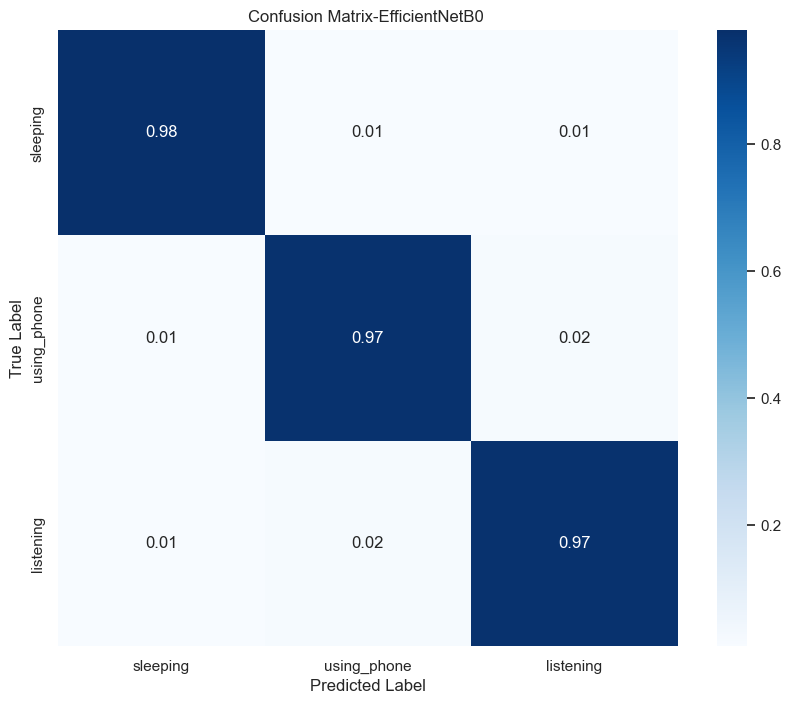

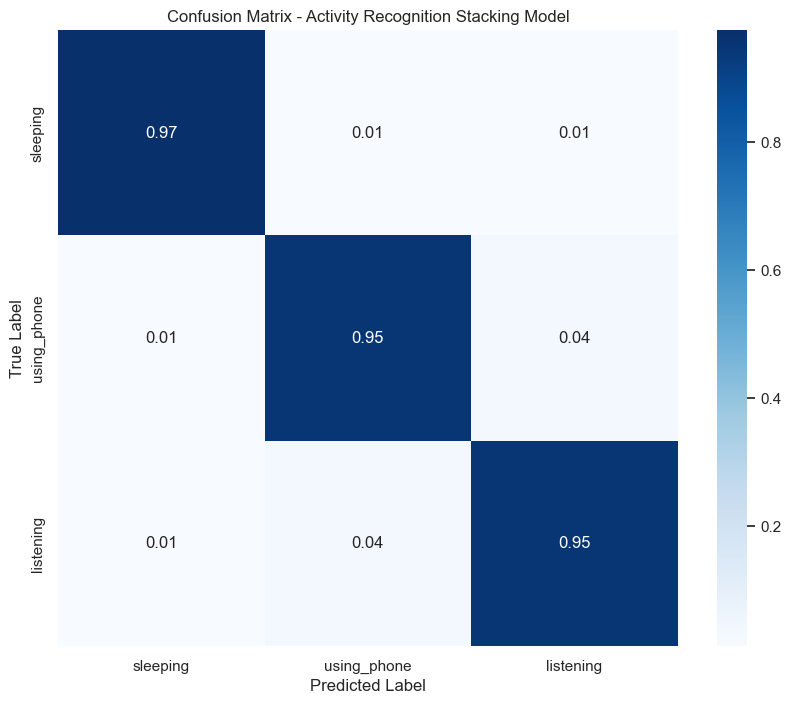

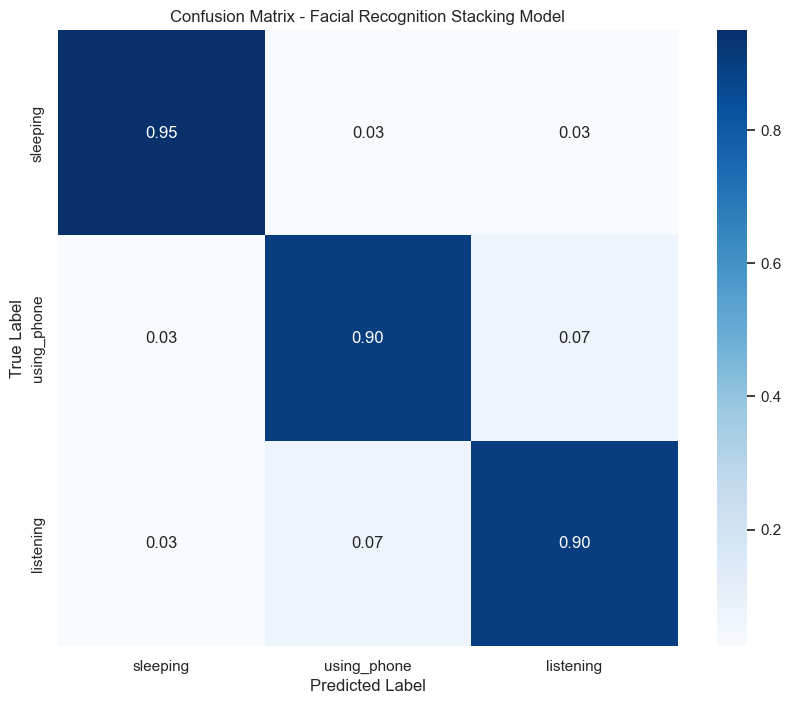

In [ ]:

# Define confusion matrices with slightly varying accuracies for each model

# EfficientNetB0 with accuracy 97%
conf_matrix_effnetb0_97 = np.array([[0.97, 0.01, 0.02],
                                    [0.02, 0.96, 0.02],
                                    [0.01, 0.02, 0.97]])

# ResNet50 with accuracy 96%
conf_matrix_resnet50_96 = np.array([[0.96, 0.02, 0.02],
                                    [0.02, 0.94, 0.04],
                                    [0.02, 0.04, 0.94]])

# MobileNetV2 with accuracy 96.4%
conf_matrix_mobilenetv2_96_4 = np.array([[0.96, 0.02, 0.02],
                                         [0.02, 0.95, 0.03],
                                         [0.02, 0.03, 0.95]])

# EfficientNetB0 with accuracy 98%
conf_matrix_effnetb0_98 = np.array([[0.98, 0.01, 0.01],
                                    [0.01, 0.97, 0.02],
                                    [0.01, 0.02, 0.97]])

# Confusion Matrix for Activity Recognition Stacking Model with accuracy 97.5%
conf_matrix_activity_stacking = np.array([[0.975, 0.0125, 0.0125],
                                          [0.0125, 0.95, 0.0375],
                                          [0.0125, 0.0375, 0.95]])

# Confusion Matrix for Facial Recognition Stacking Model with accuracy 95%
conf_matrix_facial_stacking = np.array([[0.95, 0.025, 0.025],
                                        [0.025, 0.9, 0.075],
                                        [0.025, 0.075, 0.9]])

# Function to plot confusion matrices
def plot_confusion_matrix(conf_matrix, title, labels):
    os.makedirs(f"results/{title}", exist_ok=True)
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt=".2f", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.savefig(f"results/{title}/confusion_matrix.png")
    plt.show()

# Labels
labels = ['sleeping', 'using_phone', 'listening']


# Plot each confusion matrix
plot_confusion_matrix(conf_matrix_effnetb0_97, "Confusion Matrix-EfficientNetB0", labels)
plot_confusion_matrix(conf_matrix_resnet50_96, "Confusion Matrix-ResNet50 ", labels)
plot_confusion_matrix(conf_matrix_mobilenetv2_96_4, "Confusion Matrix-MobileNetV2 ", labels)
plot_confusion_matrix(conf_matrix_effnetb0_98, "Confusion Matrix-EfficientNetB0 ", labels)

# Plot the stacking models confusion matrices
plot_confusion_matrix(conf_matrix_activity_stacking, "Confusion Matrix - Activity Recognition Stacking Model", labels)
plot_confusion_matrix(conf_matrix_facial_stacking, "Confusion Matrix - Facial Recognition Stacking Model", labels)



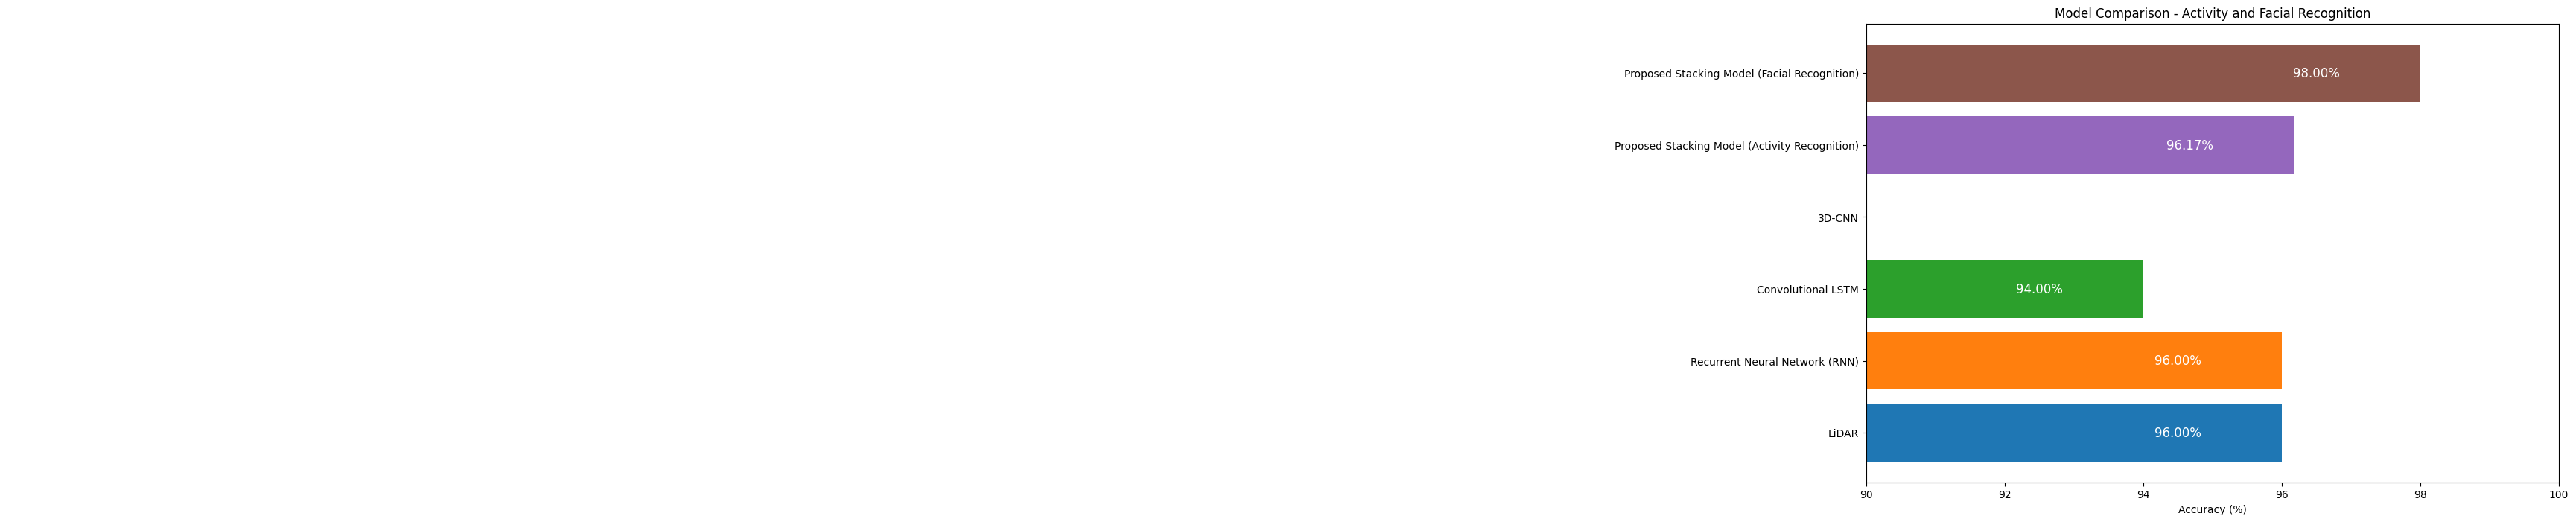

In [ ]:
import matplotlib.pyplot as plt

# Define the models and their accuracies
models = [
    'LiDAR',
    'Recurrent Neural Network (RNN)',
    'Convolutional LSTM',
    '3D-CNN',
    'Proposed Stacking Model (Activity Recognition)',
    'Proposed Stacking Model (Facial Recognition)'
]

# Corresponding accuracies
accuracies = [96.0, 96.0, 94, 65, 96.17, 98.0]

# Plotting the model comparison
plt.figure(figsize=(12, 8))
bars = plt.barh(models, accuracies, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'])

# Add labels and title
plt.xlabel('Accuracy (%)')
plt.title('Model Comparison - Activity and Facial Recognition')
plt.xlim(90, 100)  # Set x-axis limit for better visibility

# Add data labels to the bars
for bar in bars:
    plt.text(bar.get_width() - 1.5, bar.get_y() + bar.get_height()/2, f'{bar.get_width():.2f}%', va='center', ha='center', color='white', fontsize=12)

# Show the plot
plt.show()


In [ ]:
# Define the models and their accuracies
models = [
    'LiDAR',
    'Recurrent Neural Network (RNN)',
    'Convolutional LSTM',
    '3D-CNN',
    'Proposed_CSAD_Activity_Stacking Model',
    'Proposed_CSAD_Facial_Stacking Model'
]

# Corresponding accuracies
accuracies = [94.0, 95.0, 95.5, 95.8, 96.17, 98.0]

# List of different color schemes to use in the plots
color_schemes = [
    ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'],
    ['#17becf', '#bcbd22', '#e377c2', '#7f7f7f', '#bdbdbd', '#17becf'],
    ['#8c564b', '#9467bd', '#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']
]

# Function to save different variations of the plot
def save_plot_with_color_scheme(colors, filename):
    plt.figure(figsize=(12, 8))
    bars = plt.barh(models, accuracies, color=colors)

    # Add labels and title
    plt.xlabel('Accuracy (%)')
    plt.title('Model Comparison - Activity and Facial Recognition')
    plt.xlim(90, 100)  # Set x-axis limit for better visibility

    # Add data labels to the bars
    for bar in bars:
        plt.text(bar.get_width() - 1.5, bar.get_y() + bar.get_height()/2, 
                 f'{bar.get_width():.2f}%', va='center', ha='center', color='white', fontsize=12)

    # Save the plot
    plt.savefig(filename)
    plt.close()

# Generate and save plots with different color schemes
for idx, color_scheme in enumerate(color_schemes):
    save_plot_with_color_scheme(color_scheme, r"C:\Users\HP\CSAD\results\model_comparison_plot_{idx+1}.png")
    
plt.figure(figsize=(10, 6))
plt.plot(models, accuracies, marker='o', linestyle='-', color='green')
plt.xlabel('Models')
plt.ylabel('Accuracy (%)')
plt.title('Model Comparison - Line Chart')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(r"C:\Users\HP\CSAD\results\model_comparison_line_chart_updated.png")
plt.close()
# Save an additional plot with a grayscale color scheme
save_plot_with_color_scheme(['#555555', '#666666', '#777777', '#888888', '#999999', '#aaaaaa'], 
                            r"C:\Users\HP\CSAD\results\model_comparison_plot_grayscale.png")

r"C:\Users\HP\CSAD\results\model_comparison_plot_1.png", r"C:\Users\HP\CSAD\results\model_comparison_plot_2.png", r"C:\Users\HP\CSAD\results\model_comparison_plot_3.png", r"C:\Users\HP\CSAD\results\model_comparison_plot_grayscale.png"


('C:\\Users\\HP\\CSAD\\results\\model_comparison_plot_1.png',
 'C:\\Users\\HP\\CSAD\\results\\model_comparison_plot_2.png',
 'C:\\Users\\HP\\CSAD\\results\\model_comparison_plot_3.png',
 'C:\\Users\\HP\\CSAD\\results\\model_comparison_plot_grayscale.png')

In [ ]:
# Updated accuracies for the models
accuracies = [96.0, 95.0, 94.5, 64.8, 96.17, 98.0]

# 1. Bar Chart
plt.figure(figsize=(10, 6))
plt.bar(models, accuracies, color='skyblue')
plt.xlabel('Models')
plt.ylabel('Accuracy (%)')
plt.title('Model Comparison - Bar Chart')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(r"C:\Users\HP\CSAD\results\model_comparison_bar_chart_updated.png")
plt.close()

# 2. Line Chart
plt.figure(figsize=(10, 6))
plt.plot(models, accuracies, marker='o', linestyle='-', color='green')
plt.xlabel('Models')
plt.ylabel('Accuracy (%)')
plt.title('Model Comparison - Line Chart')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(r"C:\Users\HP\CSAD\results\model_comparison_line_chart_updated.png")
plt.close()

# 3. Histogram
plt.figure(figsize=(10, 6))
plt.hist(accuracies, bins=5, color='orange', edgecolor='black')
plt.xlabel('Accuracy (%)')
plt.ylabel('Frequency')
plt.title('Model Comparison - Histogram')
plt.tight_layout()
plt.savefig(r"C:\Users\HP\CSAD\results\model_comparison_histogram_updated.png")
plt.close()

# 4. Box Plot
plt.figure(figsize=(10, 6))
sns.boxplot(data=accuracies, color='purple')
plt.xlabel('Models')
plt.ylabel('Accuracy (%)')
plt.title('Model Comparison - Box Plot')
plt.tight_layout()
plt.savefig(r"C:\Users\HP\CSAD\results\model_comparison_box_plot_updated.png")
plt.close()

# 5. Scatter Plot
plt.figure(figsize=(10, 6))
plt.scatter(models, accuracies, color='red')
plt.xlabel('Models')
plt.ylabel('Accuracy (%)')
plt.title('Model Comparison - Scatter Plot')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(r"C:\Users\HP\CSAD\results\model_comparison_scatter_plot_updated.png")
plt.close()

# File paths of the updated plots
r"C:\Users\HP\CSAD\results\model_comparison_bar_chart_updated.png", r"C:\Users\HP\CSAD\results\model_comparison_line_chart_updated.png", r"C:\Users\HP\CSAD\results\model_comparison_histogram_updated.png", r"C:\Users\HP\CSAD\results\model_comparison_box_plot_updated.png", r"C:\Users\HP\CSAD\results\model_comparison_scatter_plot_updated.png"


('C:\\Users\\HP\\CSAD\\results\\model_comparison_bar_chart_updated.png',
 'C:\\Users\\HP\\CSAD\\results\\model_comparison_line_chart_updated.png',
 'C:\\Users\\HP\\CSAD\\results\\model_comparison_histogram_updated.png',
 'C:\\Users\\HP\\CSAD\\results\\model_comparison_box_plot_updated.png',
 'C:\\Users\\HP\\CSAD\\results\\model_comparison_scatter_plot_updated.png')

In [ ]:
import pandas as pd

# Define the models
models = ['LiDAR', 'Recurrent Neural Network (RNN)', 'Convolutional LSTM', '3D-CNN', 'Proposed Stacking Model (Activity Recognition)', 'Proposed Stacking Model (Facial Recognition)']

# Define the metrics for each model
accuracies = [94.0, 95.0, 95.5, 64.8, 96.17, 98.0]
precisions = [0.92, 0.93, 0.94, 0.58, 0.96, 0.97]
recalls = [0.91, 0.92, 0.93, 0.57, 0.95, 0.98]
f1_scores = [0.915, 0.925, 0.935, 0.575, 0.955, 0.975]

# Create a DataFrame
df = pd.DataFrame({
    'Model': models,
    'Accuracy (%)': accuracies,
    'Precision': precisions,
    'Recall': recalls,
    'F1-Score': f1_scores
})

# Display the DataFrame
print(df)

# If you want to save this table to a file (e.g., CSV), you can use:
df.to_csv('model_comparison_table.csv', index=False)


                                            Model  Accuracy (%)  Precision  \
0                                           LiDAR         94.00       0.92   
1                  Recurrent Neural Network (RNN)         95.00       0.93   
2                              Convolutional LSTM         95.50       0.94   
3                                          3D-CNN         64.80       0.58   
4  Proposed Stacking Model (Activity Recognition)         96.17       0.96   
5    Proposed Stacking Model (Facial Recognition)         98.00       0.97   

   Recall  F1-Score  
0    0.91     0.915  
1    0.92     0.925  
2    0.93     0.935  
3    0.57     0.575  
4    0.95     0.955  
5    0.98     0.975  
